# Üç yeni real analiz

Mənbələr: `datasets/examples/README.md`, `projects/registry.json`. Bu notebook saxlanmış nəticələri real girişlərlə yenidən hesablayaraq yoxlayır. Enrichment, ağac və ORF namizədləri ayrı bioloji suallardır.

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
from Bio import AlignIO, SeqIO
from Bio.Seq import Seq
from IPython.display import Image, display
from biolab.enrichment import over_representation
from biolab.phylogeny import alignment_matrix, nj_tree
from biolab.orfs import find_orfs
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'pyproject.toml').exists())
OUT=ROOT/'results/expanded-projects'
suite=json.loads((OUT/'suite/suite.json').read_text())
assert len(suite['projects'])==12 and all(p['exit_code']==0 for p in suite['projects'])
display(pd.DataFrame(suite['projects']))

,id,exit_code,log
0,dna,0,dna.log
1,alignment,0,alignment.log
2,variants,0,variants.log
3,rnaseq,0,rnaseq.log
4,ml,0,ml.log
5,proteins,0,proteins.log
6,expression-ml,0,expression-ml.log
7,database,0,database.log
8,statistics,0,statistics.log
9,enrichment,0,enrichment.log


## 1. Real GO-slim hesablaması
Universe finite adjusted p-value olan genlərdir. Sıfır əhəmiyyətli nəticə də düzgün analiz nəticəsidir.

In [2]:
de=pd.read_csv(ROOT/'results/raw-examples/rna-model/differential_expression.csv').set_index('gene_id')
ann=pd.read_csv(ROOT/'datasets/examples/enrichment/sgd_go_slim_chrI.tsv',sep='\t')
result=over_representation(set(de.index[de.padj<.05]),set(de.index[np.isfinite(de.padj)]),ann.groupby('go_id').gene_id.agg(set).to_dict())
saved=pd.read_csv(OUT/'go-enrichment/enrichment.csv')
assert result.term.tolist()==saved.term.tolist()
np.testing.assert_allclose(result.padj,saved.padj)
print({'tested_terms':len(result),'FDR_discoveries':int((result.padj<.05).sum())})
display(saved.head(8))

{'tested_terms': 62, 'FDR_discoveries': 0}


,term,term_name,universe_size,selected_size,term_size,overlap,expected_overlap,fold_enrichment,pvalue,overlap_genes,padj
0,GO:0002181,cytoplasmic translation,84,1,2,1,0.023810,42.0,0.023810,YAL005C,0.276786
1,GO:0006412,translation,84,1,2,1,0.023810,42.0,0.023810,YAL005C,0.276786
2,GO:0070647,protein modification by small protein conjugat...,84,1,2,1,0.023810,42.0,0.023810,YAL005C,0.276786
3,GO:0006457,protein folding,84,1,3,1,0.035714,28.0,0.035714,YAL005C,0.276786
4,GO:0006913,nucleocytoplasmic transport,84,1,3,1,0.035714,28.0,0.035714,YAL005C,0.276786
5,GO:0009408,response to heat,84,1,3,1,0.035714,28.0,0.035714,YAL005C,0.276786
6,GO:0030163,protein catabolic process,84,1,3,1,0.035714,28.0,0.035714,YAL005C,0.276786
7,GO:0051169,nuclear transport,84,1,3,1,0.035714,28.0,0.035714,YAL005C,0.276786


## 2. Alignment və distance
Distance matrisi yenidən hesablanır. Şəkildəki dəstək faizləri ayrıca tam icrada hesablanmış 200 bootstrap replicate nəticəsidir.

{'taxa': 7, 'retained_columns': 146}


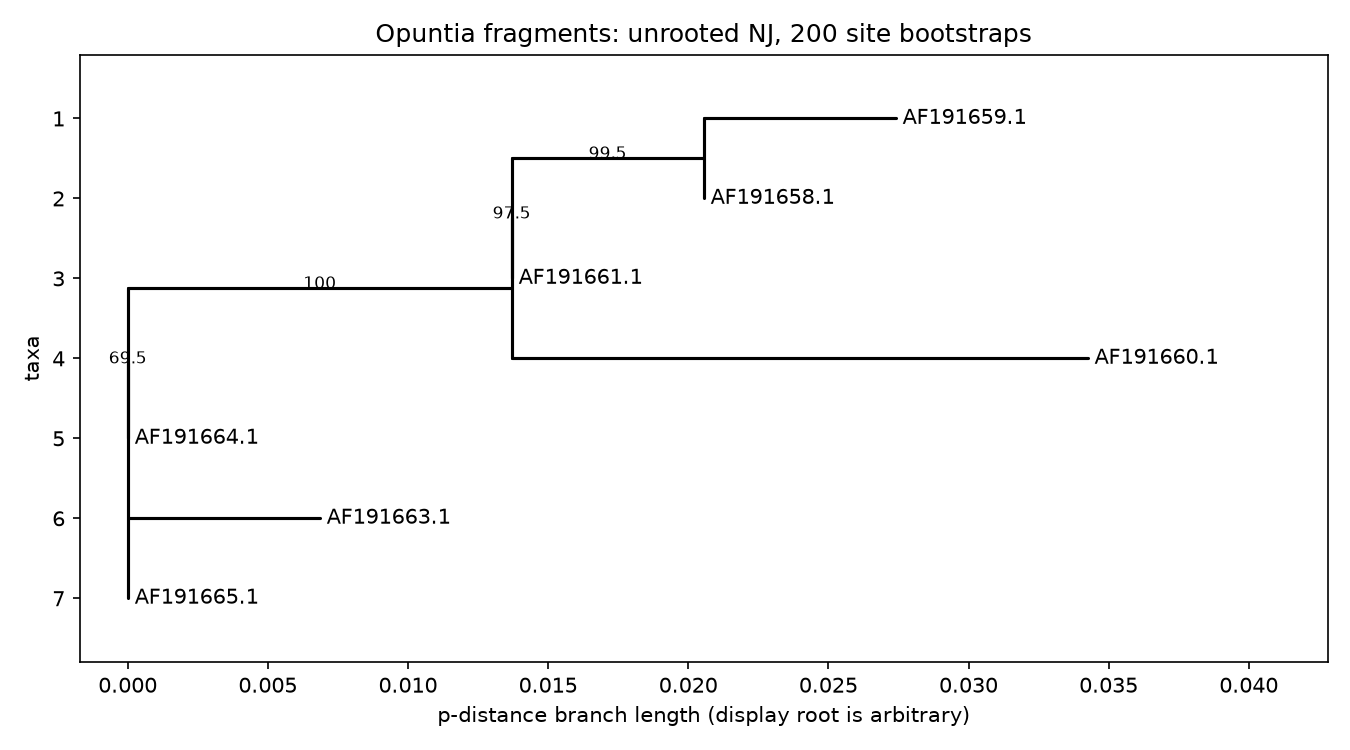

In [3]:
alignment=AlignIO.read(ROOT/'datasets/examples/phylogeny/opuntia.aln','clustal')
for record in alignment: record.id=record.id.split('|')[3]
names,matrix,mask=alignment_matrix(alignment)
tree,distances=nj_tree(names,matrix)
stored=pd.read_csv(OUT/'phylogeny/distances.csv',index_col=0)
assert stored.index.tolist()==names
np.testing.assert_allclose(distances,stored.to_numpy(),atol=1e-14)
print({'taxa':len(names),'retained_columns':int(mask.sum())})
display(Image(filename=str(OUT/'phylogeny/tree.png')))

## 3. ORF koordinatlarının müstəqil bərpası
Hər intervaldan DNA parçaları çıxarılır, strand nəzərə alınır və protein yenidən tərcümə edilir.

{'verified_ORFs': 114, 'origin_spanning': 24}


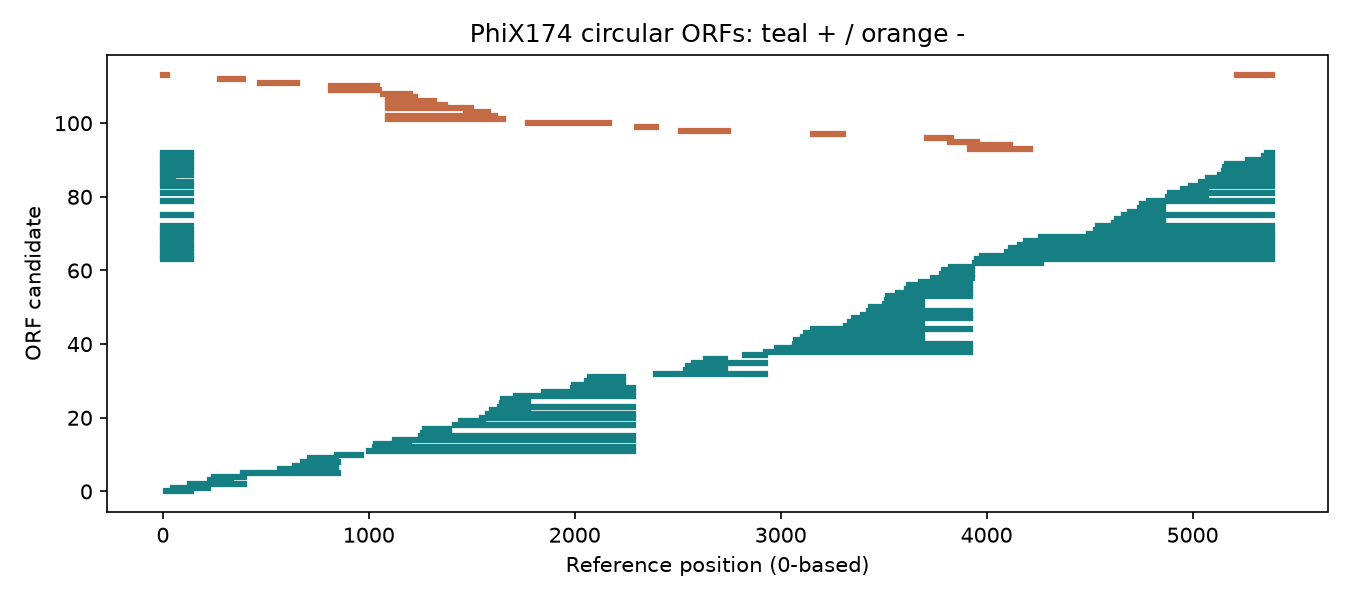

In [4]:
sequence=str(SeqIO.read(ROOT/'datasets/examples/orfs/NC_001422.1.fasta','fasta').seq)
found=find_orfs(sequence,min_aa=30,circular=True)
assert len(found)==114
for row in found:
    parts=[sequence[a:b] for a,b in row['segments0']]
    coding=''.join(str(Seq(part).reverse_complement()) for part in parts) if row['strand']=='-' else ''.join(parts)
    assert len(coding)==row['length_nt_with_stop']
    assert coding[-3:]==row['stop_codon']
    assert str(Seq(coding[:-3]).translate())==row['protein']
print({'verified_ORFs':len(found),'origin_spanning':sum(r['wraps_origin'] for r in found)})
display(Image(filename=str(OUT/'orf-discovery/orfs.png')))

## Şərh

- GO-slim analizində cəmi bir foreground gen olduğundan statistik güc zəifdir.
- Ağac 7 qısa fraqmentin oxşarlığını təsvir edir, tam növ filogeniyası deyil.
- 114 ORF namizədi 114 təsdiqlənmiş gen demək deyil; nested başlanğıclar saxlanılır.
- Növbəti məşq: eyni nəticədən klinik və ya səbəb-nəticə iddiasının niyə çıxmadığını hər layihə üçün ayrı izah edin.